In [55]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from hbn.constants import Defaults
from hbn.visualization import visualize

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

%matplotlib inline

#pio.renderers.default = 'iframe'
import plotly.io as pio
pio.renderers.default='notebook'

from hbn.visualization import visualize

visualize.plotting_style()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# load data

dirn = '/Users/maedbhking/Documents/healthy_brain_network/data/interim/models/2023-04-01_18-18-41-72/model_395065402/'
df = pd.read_csv(os.path.join(dirn, 'evaluation_all.csv'))

In [52]:
from hbn.models.predictive_modeling import calculate_R, calculate_R2
from sklearn.metrics import mean_squared_error

df_all = pd.DataFrame()
for group in df.groupby('predict'):
    df1 = group[1]
    y = df1['y']
    y_pred = df1['y_pred']

    # calculate RMSE etc
    df1['R'] = calculate_R(y, y_pred)
    df1['R2'] = calculate_R2(y, y_pred)
    #df1['R2_sk'] = r2_score(y, y_pred)
    df1['rmse'] = mean_squared_error(y, y_pred, squared=False)
    
    df_all = pd.concat([df_all, df1])
    

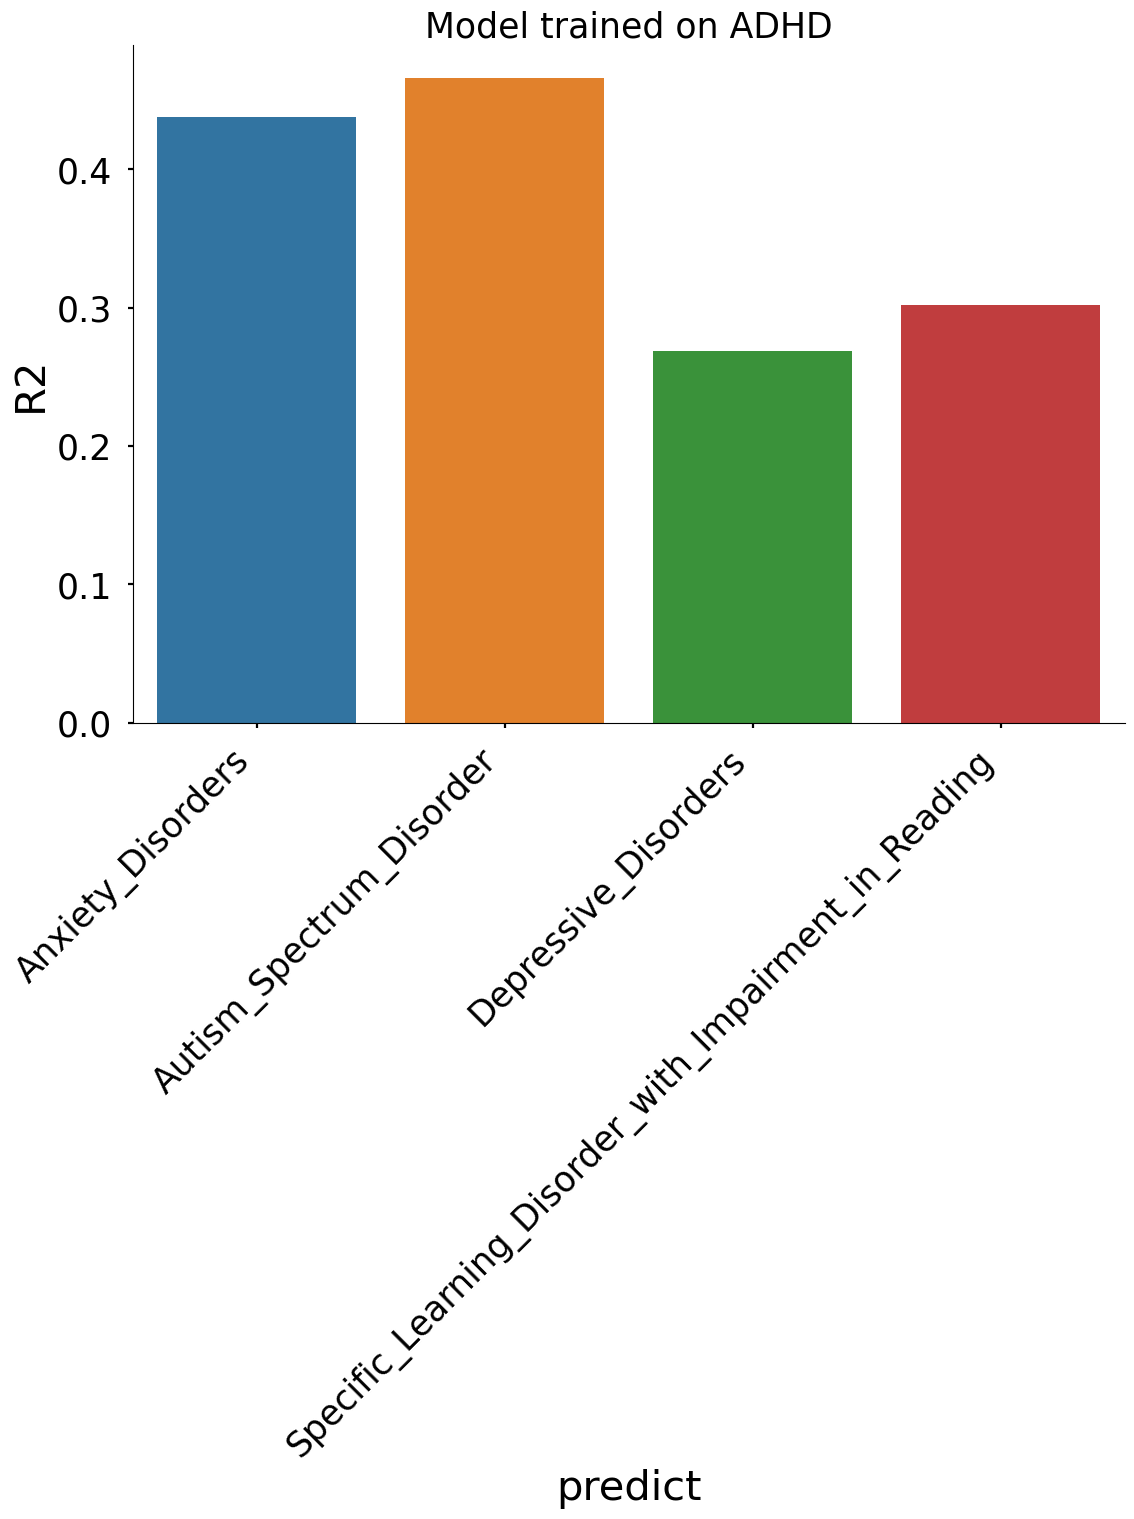

In [56]:
sns.barplot(x='predict', y='R2', data=df_all)
plt.xticks(rotation=45, ha='right');
#plt.ylim([0.5, 1])
plt.title('Model trained on ADHD');

## Get comorbidities for ADHD

In [208]:
from hbn.data import make_dataset
import numpy as np

dx = make_dataset.make_summary(save=False)

data_dict = {'Anxiety': 'DX_02',
             'Depressive Disorders': 'DX_02_Cat',
            'Specific Learning Disorder with Impairment in Reading': 'DX_02',
            'Autism Spectrum Disorder': 'DX_02'
            }

df_adhd = dx[dx['DX_01_Cat_new']=='ADHD']

list_vals =np.arange(2,11)

vals = []; v_new_all = []; diagnoses = []; percent_all=[]
for num in list_vals:
    for k,v in data_dict.items():
        
        if len(v.split('_'))==3:
            v_new = v.split('_')[0] + "_%02.f"%num + '_' +  v.split('_')[2]
        else:
            v_new = v.split('_')[0] + "_%02.f"%num 
        v_new_all.append(v_new)
        
        diagnoses.append(k)
        
        val = np.nansum(df_adhd[v_new].str.contains(k))
        percent = (np.nansum(df_adhd[v_new].str.contains(k)) / df_adhd.shape[0]) *100
        vals.append(val)
        percent_all.append(percent)
        
# make dataframe
df_co = pd.DataFrame()
df_co['diagnosis'] = diagnoses
df_co['vals'] = vals
df_co['percent'] = percent_all
df_co['cat'] = v_new_all
df_co['comorbidites'] = df_co['cat'].str.extract('(\d+)')

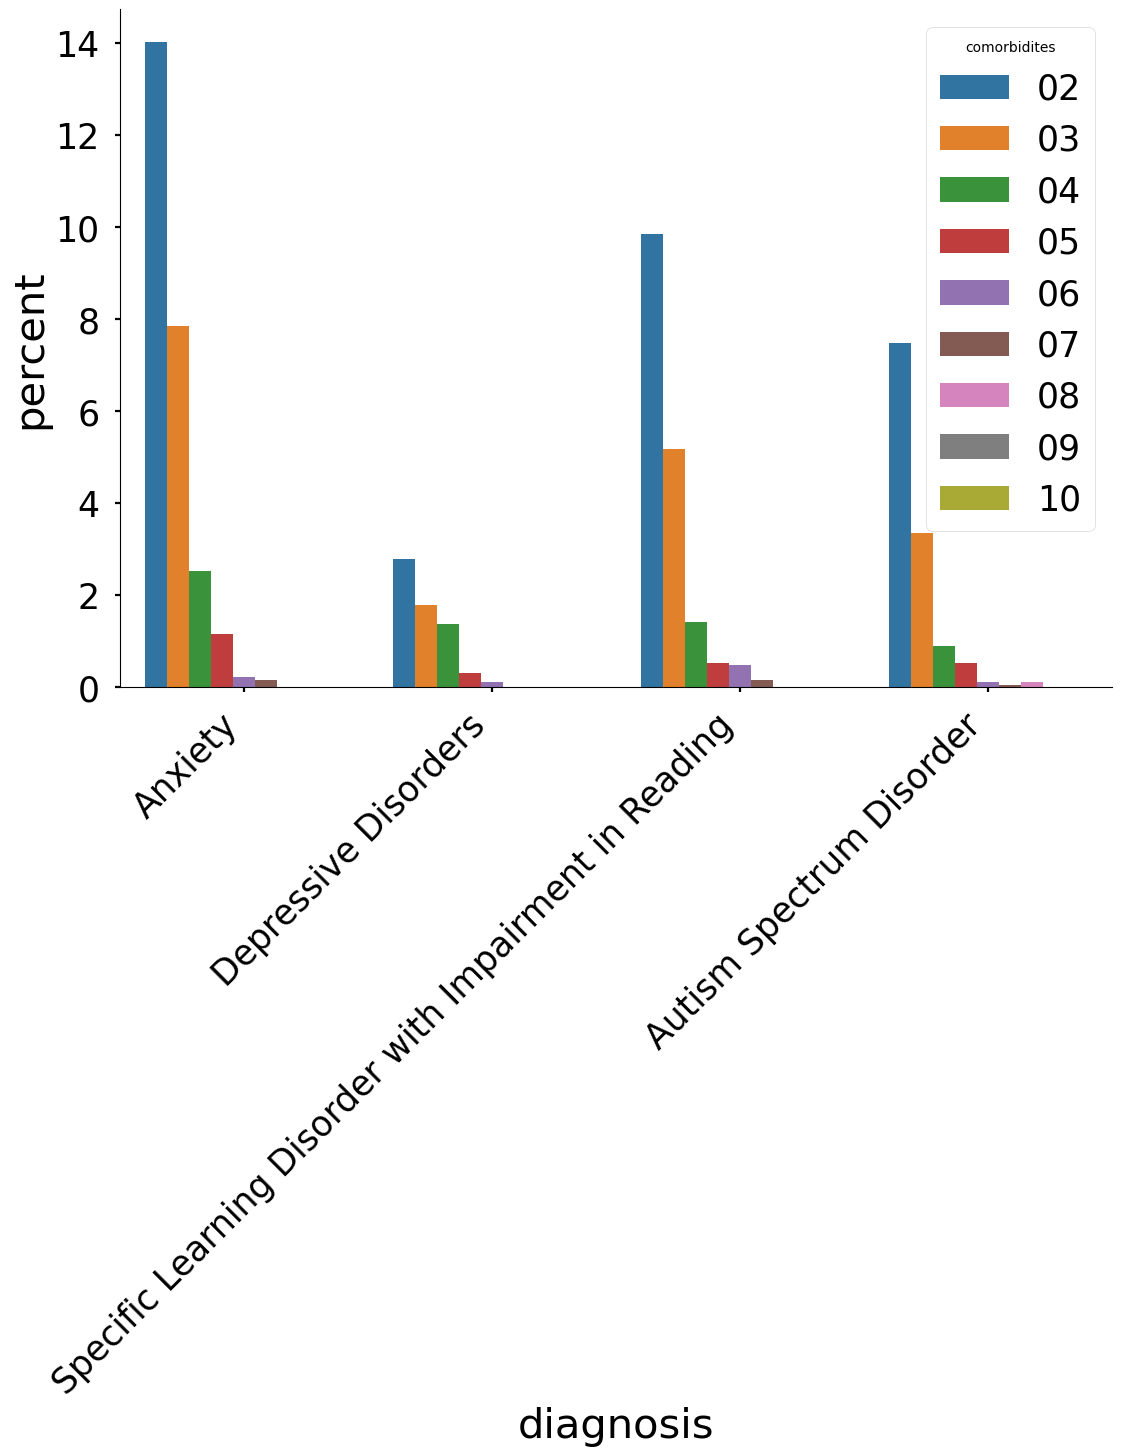

In [214]:
sns.barplot(x='diagnosis', y='percent', hue='comorbidites', data=df_co)

plt.xticks(rotation=45, ha='right');

In [220]:
import plotly.express as px

fig = px.bar(df_co, y="diagnosis", x="percent", color="comorbidites", orientation='h')
fig.update_layout({'plot_bgcolor': 'rgba(0,0,0,0)'})
fig.show()